In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


In [8]:
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('muted')

In [11]:
df = pd.read_csv(r"C:\Users\Anom\Downloads\archive\DataCoSupplyChainDataset.csv", encoding='latin1',
                 parse_dates=['order date (DateOrders)', 'shipping date (DateOrders)'])

# Standardise column names
df.columns = (df.columns
              .str.strip()
              .str.lower()
              .str.replace(' ', '_')
              .str.replace('(', '', regex=False)
              .str.replace(')', '', regex=False))

print(f"Rows: {len(df):,}   Columns: {df.shape[1]}")

Rows: 180,519   Columns: 53


In [12]:
# Drop junk columns
drop_cols = ['customer_email', 'customer_fname', 'customer_lname',
             'customer_password', 'customer_street', 'product_description',
             'product_image', 'order_zipcode']
df.drop(columns=[c for c in drop_cols if c in df.columns], inplace=True)

df['customer_zipcode'].fillna(0, inplace=True)

# Parse dates
df['order_date'] = pd.to_datetime(df['order_date_dateorders'], errors='coerce')
df['ship_date']  = pd.to_datetime(df['shipping_date_dateorders'], errors='coerce')

# Derived columns
df['ship_delay_days'] = df['days_for_shipping_real'] - df['days_for_shipment_scheduled']
df['is_late']         = (df['ship_delay_days'] > 0).astype(int)
df['order_month']     = df['order_date'].dt.to_period('M')
df['order_year']      = df['order_date'].dt.year
df['is_loss_order']   = (df['order_profit_per_order'] < 0).astype(int)

# Discount band
bins   = [-0.001, 0.0, 0.10, 0.20, 0.30, 1.01]
labels = ['No Discount', '0-10%', '10-20%', '20-30%', '30%+']
df['discount_band'] = pd.cut(df['order_item_discount_rate'], bins=bins, labels=labels)

print(df[['ship_delay_days','is_late','is_loss_order','discount_band']].head())
print(df['discount_band'].value_counts())

   ship_delay_days  is_late  is_loss_order discount_band
0               -1        0              0         0-10%
1                1        1              1         0-10%
2                0        0              1         0-10%
3               -1        0              0         0-10%
4               -2        0              0         0-10%
discount_band
0-10%          80230
10-20%         70203
20-30%         20058
No Discount    10028
30%+               0
Name: count, dtype: int64


In [13]:
total_revenue  = df['sales'].sum()
total_profit   = df['order_profit_per_order'].sum()
profit_margin  = (total_profit / total_revenue) * 100
loss_orders    = df['is_loss_order'].sum()
loss_pct       = (loss_orders / len(df)) * 100
late_rate      = df['is_late'].mean() * 100

print(f"Total Revenue   : ${total_revenue:>15,.2f}")
print(f"Total Profit    : ${total_profit:>15,.2f}")
print(f"Profit Margin   : {profit_margin:>14.2f}%")
print(f"Loss Orders     : {loss_orders:>15,}  ({loss_pct:.1f}% of all orders)")
print(f"Late Delivery % : {late_rate:>14.1f}%")

Total Revenue   : $  36,784,735.01
Total Profit    : $   3,966,902.97
Profit Margin   :          10.78%
Loss Orders     :          33,784  (18.7% of all orders)
Late Delivery % :           57.3%


                      total_profit  total_sales  order_count  margin_pct
category_name                                                           
Strength Training           332.31     54895.53          111        0.61
CDs                         383.85      3059.59          271       12.55
As Seen on  TV!             714.43     20597.94           68        3.47
Books                       883.01     12587.40          405        7.02
Toys                        900.71      6104.66          529       14.75
Baby                       1525.03     12229.56          207       12.47
Golf Bags & Carts          1810.07     10369.39           61       17.46
Basketball                 1845.67     27099.33           67        6.81
Men's Clothing             2006.04     43856.80          208        4.57
Video Games                2717.52     33310.50          838        8.16
Golf Apparel               3496.31     34969.75          441       10.00
Pet Supplies               3589.26     41524.80    

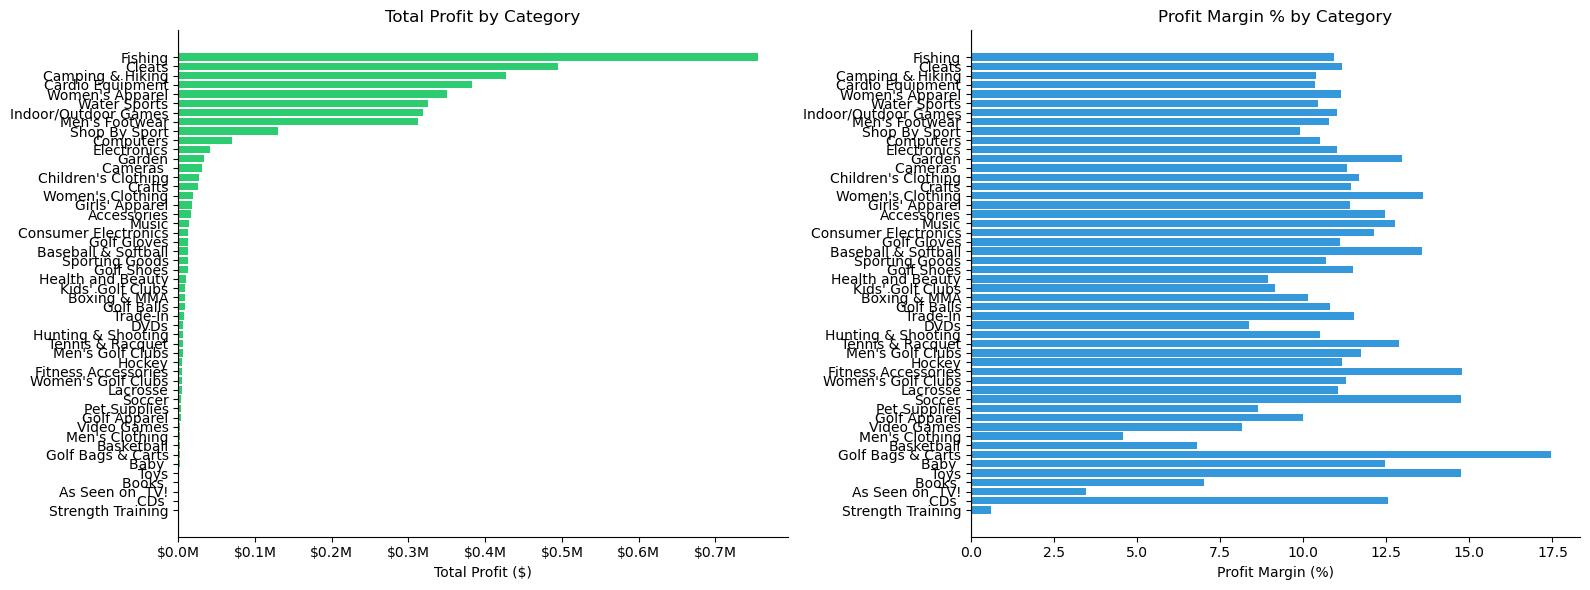

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors = ['#e74c3c' if v < 0 else '#2ecc71' for v in cat_profit['total_profit']]
axes[0].barh(cat_profit.index, cat_profit['total_profit'], color=colors)
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_xlabel('Total Profit ($)')
axes[0].set_title('Total Profit by Category')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1e6:.1f}M'))

colors2 = ['#e74c3c' if v < 0 else '#3498db' for v in cat_profit['margin_pct']]
axes[1].barh(cat_profit.index, cat_profit['margin_pct'], color=colors2)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_xlabel('Profit Margin (%)')
axes[1].set_title('Profit Margin % by Category')

plt.tight_layout()
plt.savefig('category_profitability.png', dpi=150, bbox_inches='tight')
plt.show()

In [17]:
discount_profit = (df.groupby('discount_band', observed=True)
                    .agg(avg_profit    =('order_profit_per_order','mean'),
                         total_profit  =('order_profit_per_order','sum'),
                         order_count   =('order_id','count'),
                         loss_orders   =('is_loss_order','sum'))
                    .assign(loss_rate_pct=lambda x:(x['loss_orders']/x['order_count'])*100))

print(discount_profit.round(2).to_string())

               avg_profit  total_profit  order_count  loss_orders  loss_rate_pct
discount_band                                                                   
No Discount         26.67     267412.40        10028         1843          18.38
0-10%               23.39    1876272.39        80230        14891          18.56
10-20%              20.71    1454008.72        70203        13233          18.85
20-30%              18.41     369209.46        20058         3817          19.03


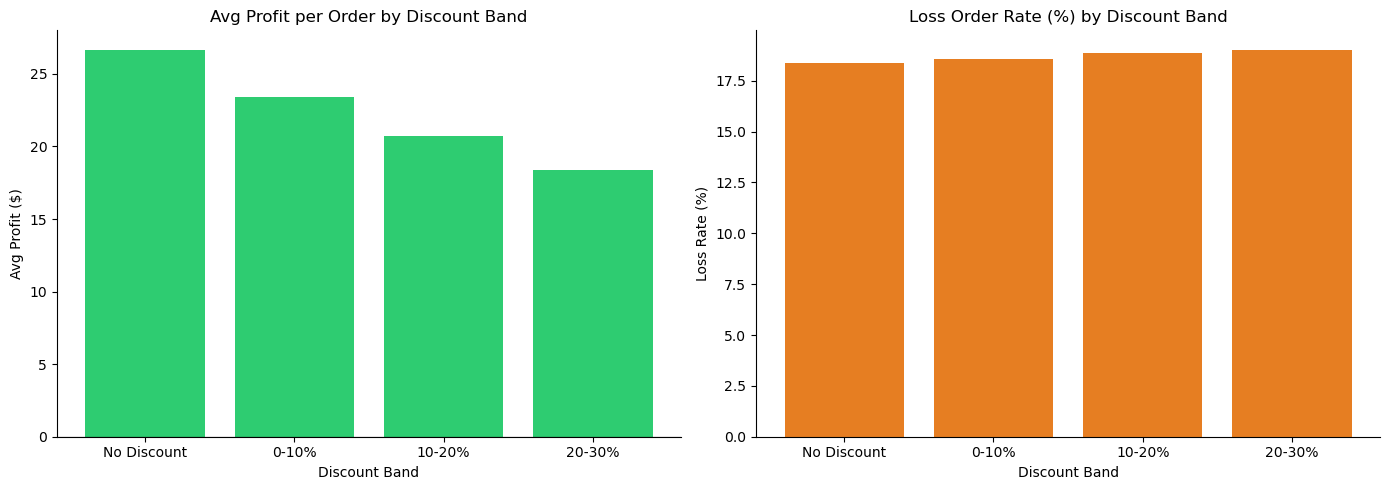

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(discount_profit.index.astype(str), discount_profit['avg_profit'],
            color=['#2ecc71' if v>0 else '#e74c3c' for v in discount_profit['avg_profit']])
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].set_title('Avg Profit per Order by Discount Band')
axes[0].set_xlabel('Discount Band')
axes[0].set_ylabel('Avg Profit ($)')

axes[1].bar(discount_profit.index.astype(str), discount_profit['loss_rate_pct'], color='#e67e22')
axes[1].set_title('Loss Order Rate (%) by Discount Band')
axes[1].set_xlabel('Discount Band')
axes[1].set_ylabel('Loss Rate (%)')

plt.tight_layout()
plt.savefig('discount_abuse.png', dpi=150, bbox_inches='tight')
plt.show()

In [19]:
print(df.columns.tolist())

['type', 'days_for_shipping_real', 'days_for_shipment_scheduled', 'benefit_per_order', 'sales_per_customer', 'delivery_status', 'late_delivery_risk', 'category_id', 'category_name', 'customer_city', 'customer_country', 'customer_id', 'customer_segment', 'customer_state', 'customer_zipcode', 'department_id', 'department_name', 'latitude', 'longitude', 'market', 'order_city', 'order_country', 'order_customer_id', 'order_date_dateorders', 'order_id', 'order_item_cardprod_id', 'order_item_discount', 'order_item_discount_rate', 'order_item_id', 'order_item_product_price', 'order_item_profit_ratio', 'order_item_quantity', 'sales', 'order_item_total', 'order_profit_per_order', 'order_region', 'order_state', 'order_status', 'product_card_id', 'product_category_id', 'product_name', 'product_price', 'product_status', 'shipping_date_dateorders', 'shipping_mode', 'order_date', 'ship_date', 'ship_delay_days', 'is_late', 'order_month', 'order_year', 'is_loss_order', 'discount_band']


In [21]:
from sqlalchemy import create_engine
import pandas as pd

engine = create_engine(
    "mssql+pyodbc://localhost\\SQLEXPRESS/DataCoSupplyChain"
    "?driver=ODBC+Driver+18+for+SQL+Server"
    "&Trusted_Connection=yes"
    "&TrustServerCertificate=yes"
)

df = pd.read_sql("SELECT * FROM supply_chain_cleaned", engine)
print(f"Rows: {len(df)}  Columns: {df.shape[1]}")

Rows: 159763  Columns: 34
